# 6. Evaluation

- **1.** Consistency and robustness of findings across methods
- **2.** Coherence and interpretability of issue categories
- **3.** Alignment with intuitive or expected patterns and with the initial clustering analysis

In [32]:
# Import the necessary modules
import numpy as np
import pandas as pd
import sys
import os
import pickle
from itertools import combinations
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import AgglomerativeClustering
from scipy.stats import entropy, kruskal
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from pathlib import Path

In [33]:
def find_root():
    cwd = Path.cwd()
    core_name = "EMATM0067_2025_TB-2-g43"
    
    for path in [cwd] + list(cwd.parents):
        if path.name.startswith(core_name):
            return path
            
    for path in cwd.rglob(f"{core_name}*"):
        if path.is_dir():
            return path
            
    return cwd

root_path = find_root()

# Convert to absolute path for reliability
root_path = root_path.resolve()

if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

# Switch to the project root
os.chdir(root_path)

reports_dir = root_path / 'reports'
figures_dir = reports_dir / 'figures'
tables_dir = reports_dir / 'tables'

# Create folders if they don't exist
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

data_file = root_path / 'data' / 'raw' / 'customer_support_tickets.csv'

if data_file.exists():
    print("PROJECT INITIALIZATION SUCCESSFUL")
    print(f"Project Root: {root_path}")
    print(f"Data Source: {data_file}")
    print(f"Figures will be saved to:\n {figures_dir}")
    print(f"Tables will be saved to:\n {tables_dir}")
else:
    print(f"ERROR: Data file not found at:\n {data_file}")
    print("Please ensure the 'data/raw' folder exists inside the project directory.")

PROJECT INITIALIZATION SUCCESSFUL
Project Root: E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP
Data Source: E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\data\raw\customer_support_tickets.csv
Figures will be saved to:
 E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\reports\figures
Tables will be saved to:
 E:\Study\Bristol\IATA\Group_Project\Code\EMATM0067_2025_TB-2-g43-ThiruvelAP\reports\tables


In [34]:
from src.pipeline.Preprocessing import (to_lower, expand_contractions,
                                        replace_product_purchased, remove_noise, tokenize_text, remove_stopwords_all,
                                        filter_short_tokens, lemmatize_tokens)

In [35]:
# Load raw tickets
source_data_dir = os.path.join(root_path, 'data', 'raw')
file_path = os.path.join(source_data_dir, 'customer_support_tickets.csv')
df = pd.read_csv(file_path)
print(f"Loaded {len(df)} tickets")
print(df.head())

Loaded 8469 tickets
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  P

In [36]:
def preprocess_text(text_description: pd.Series):
    text = text_description.copy()
    text = text.apply(to_lower)
    text = text.apply(expand_contractions)
    text = text.apply(replace_product_purchased)
    text = text.apply(remove_noise)
    tokens = text.apply(tokenize_text)
    tokens = tokens.apply(remove_stopwords_all)
    tokens = tokens.apply(filter_short_tokens)
    tokens = tokens.apply(lemmatize_tokens)
    return tokens

## Load Saved Models and Evaluation Artefacts

In [37]:
# ── Topic modelling models ────────────────────────────────────────────────────
models_dir = os.path.join(root_path, 'models', 'topic_modelling')

with open(os.path.join(models_dir, 'model_registry.pkl'), 'rb') as f:
    registry = pickle.load(f)

# Best LDA BoW
with open(registry['lda_bow']['model_path'], 'rb') as f:
    lda_best_bow = pickle.load(f)
with open(registry['lda_bow']['dict_path'], 'rb') as f:
    gensim_dict_bow = pickle.load(f)
with open(registry['lda_bow']['vectorizer_path'], 'rb') as f:
    bow_vectorizer = pickle.load(f)
best_bow_n_topics = registry['lda_bow']['best_n_topics']

# Best LDA TF-IDF
with open(registry['lda_tfidf']['model_path'], 'rb') as f:
    lda_best_tfidf = pickle.load(f)
with open(registry['lda_tfidf']['dict_path'], 'rb') as f:
    gensim_dict_tfidf = pickle.load(f)
with open(registry['lda_tfidf']['vectorizer_path'], 'rb') as f:
    tfidf_vectorizer = pickle.load(f)
best_tfidf_n_topics = registry['lda_tfidf']['best_n_topics']

# BERTopic
topic_model = BERTopic.load(registry['bertopic']['model_path'])
with open(registry['bertopic']['train_topics_path'], 'rb') as f:
    bert_train_data = pickle.load(f)
with open(registry['bertopic']['test_topics_path'], 'rb') as f:
    bert_test_data = pickle.load(f)

# Saved evaluation results from training phase
with open(registry['eval_results']['bow'], 'rb') as f:
    results_bow = pickle.load(f)
with open(registry['eval_results']['tfidf'], 'rb') as f:
    results_tfidf = pickle.load(f)

print(f"LDA BoW model     : {best_bow_n_topics} topics")
print(f"LDA TF-IDF model  : {best_tfidf_n_topics} topics")
print(f"BERTopic model loaded")
print(f"Evaluation results loaded")

LDA BoW model     : 8 topics
LDA TF-IDF model  : 7 topics
BERTopic model loaded
Evaluation results loaded


In [38]:
# ── Clustering labels (saved from the clustering notebook) ───────────────────
clustering_dir = os.path.join(root_path, 'models', 'clustering')

with open(os.path.join(clustering_dir, 'clustering_labels.pkl'), 'rb') as f:
    clustering_data = pickle.load(f)

km_tfidf_labels = clustering_data['km_tfidf_labels']
km_sbert_labels = clustering_data['km_sbert_labels']
X_tfidf         = clustering_data['X_tfidf']      # sparse TF-IDF matrix (full dataset)
X_sbert         = clustering_data['X_sbert']       # SBERT embeddings (full dataset)

print(f"KMeans TF-IDF labels : {np.unique(km_tfidf_labels).size} clusters")
print(f"KMeans SBERT labels  : {np.unique(km_sbert_labels).size} clusters")
print(f"X_tfidf shape        : {X_tfidf.shape}")
print(f"X_sbert shape        : {X_sbert.shape}")

KMeans TF-IDF labels : 5 clusters
KMeans SBERT labels  : 5 clusters
X_tfidf shape        : (8469, 3642)
X_sbert shape        : (8469, 384)


In [39]:
# ── Sentiment scores (saved from the SentimentAnalysis notebook) ─────────────
# Merge saved sentiment columns onto df so we don't recompute them here.
data_dir = os.path.join(root_path, 'data', 'processed')
sentiment_path = os.path.join(data_dir, 'sentiment_scored.csv')

sentiment_cols = ['vader_compound', 'vader_pos', 'vader_neu', 'vader_neg',
                  'vader_label', 'tb_polarity', 'tb_subjectivity', 'tb_label']
sentiment_df = pd.read_csv(sentiment_path)[sentiment_cols]

# Drop any stale sentiment columns that might already be on df, then merge
df = df.drop(columns=[c for c in sentiment_cols if c in df.columns], errors='ignore')
df = pd.concat([df.reset_index(drop=True), sentiment_df.reset_index(drop=True)], axis=1)

# Word count (used in BERTopic outlier analysis)
if 'word_count' not in df.columns:
    df['word_count'] = df['Ticket Description'].str.split().str.len()

print(f"Sentiment columns merged. df shape: {df.shape}")
print(f"VADER label distribution:\n{df['vader_label'].value_counts().to_string()}")

Sentiment columns merged. df shape: (8469, 26)
VADER label distribution:
vader_label
Positive    6000
Negative    2109
Neutral      360


## Prepare Evaluation Data

Reproduce the **exact same train/test split** used during training (same `random_state=42`).
Use `.transform()` — not `.fit_transform()` — so the saved vocabulary and IDF weights are preserved.

In [40]:
train_idx, test_idx = train_test_split(
    range(len(df)), test_size=0.2, random_state=42
)

# Preprocess text
tokens     = preprocess_text(df['Ticket Description'])
clean_text = tokens.apply(lambda t: ' '.join(t))

train_text        = [clean_text.iloc[i] for i in train_idx]
test_text         = [clean_text.iloc[i] for i in test_idx]
train_token_lists = [tokens.iloc[i]     for i in train_idx]
test_token_lists  = [tokens.iloc[i]     for i in test_idx]

# ── Transform with LOADED vectorizers (vocabulary is frozen from training) ──
X_bow_train  = bow_vectorizer.transform(train_text)
X_bow_test   = bow_vectorizer.transform(test_text)
X_lda_train  = tfidf_vectorizer.transform(train_text)
X_lda_test   = tfidf_vectorizer.transform(test_text)

feature_names_bow = bow_vectorizer.get_feature_names_out()
feature_names_lda = tfidf_vectorizer.get_feature_names_out()

print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")
print(f"BoW  vocab: {X_bow_train.shape[1]} | TF-IDF vocab: {X_lda_train.shape[1]}")

Train: 6775 | Test: 1694
BoW  vocab: 5000 | TF-IDF vocab: 2994


In [ ]:
from gensim.matutils import Sparse2Corpus

# Define a helper function: converts sparse matrices to a Gensim-compatible format and extracts the standard probability matrix
def get_dense_probs(model, X_sparse, n_topics):
    corpus = Sparse2Corpus(X_sparse, documents_columns=False)
    probs = np.zeros((X_sparse.shape[0], n_topics))
    for i, doc_topics in enumerate(model[corpus]):
        for topic_id, prob in doc_topics:
            probs[i, topic_id] = prob
    return probs

# Apply loaded LDA TF-IDF model to get per-document topic distributions
lda_train_probs = get_dense_probs(lda_best_tfidf, X_lda_train, best_tfidf_n_topics)
lda_test_probs  = get_dense_probs(lda_best_tfidf, X_lda_test,  best_tfidf_n_topics)

# Reconstruct a full-dataset topic distribution matrix (aligned to df index)
lda_topic_dist = np.empty((len(df), best_tfidf_n_topics))
lda_topic_dist[list(train_idx)] = lda_train_probs
lda_topic_dist[list(test_idx)]  = lda_test_probs

# Hard-assign each document to its dominant topic
lda_tfidf_labels = lda_topic_dist.argmax(axis=1)
df['lda_topic']  = lda_tfidf_labels
lda_labels       = lda_tfidf_labels

# Reconstruct BERTopic full-dataset topic array from saved train+test data
topics_train = bert_train_data['topics']
probs_train  = bert_train_data['probs']
topics_test  = bert_test_data['test_topics']
probs_test   = bert_test_data['test_probs']

topics_all = np.empty(len(df), dtype=int)
topics_all[list(train_idx)] = topics_train
topics_all[list(test_idx)]  = topics_test

# BoW LDA topic assignment (for BoW-specific evaluations)
lda_bow_train_probs = get_dense_probs(lda_best_bow, X_bow_train, best_bow_n_topics)
lda_bow_test_probs  = get_dense_probs(lda_best_bow, X_bow_test,  best_bow_n_topics)

print(f"LDA TF-IDF topic label distribution:")
print(pd.Series(lda_tfidf_labels).value_counts().sort_index().to_string())
print(f"\nBERTopic — outliers: {(topics_all == -1).sum()} | valid: {(topics_all != -1).sum()}")

LDA TF-IDF topic label distribution:
0    1414
1    1274
2    1714
3    1055
4    1366
5    1064
6     582

BERTopic — outliers: 1168 | valid: 7301


## LDA Evaluation: Coherence & Perplexity

Plots coherence and perplexity **from the results saved during the training sweep** — no retraining.
Then evaluates the loaded best models on the held-out test split.

Saved figure: evaluation_lda_coherence_perplexity.png


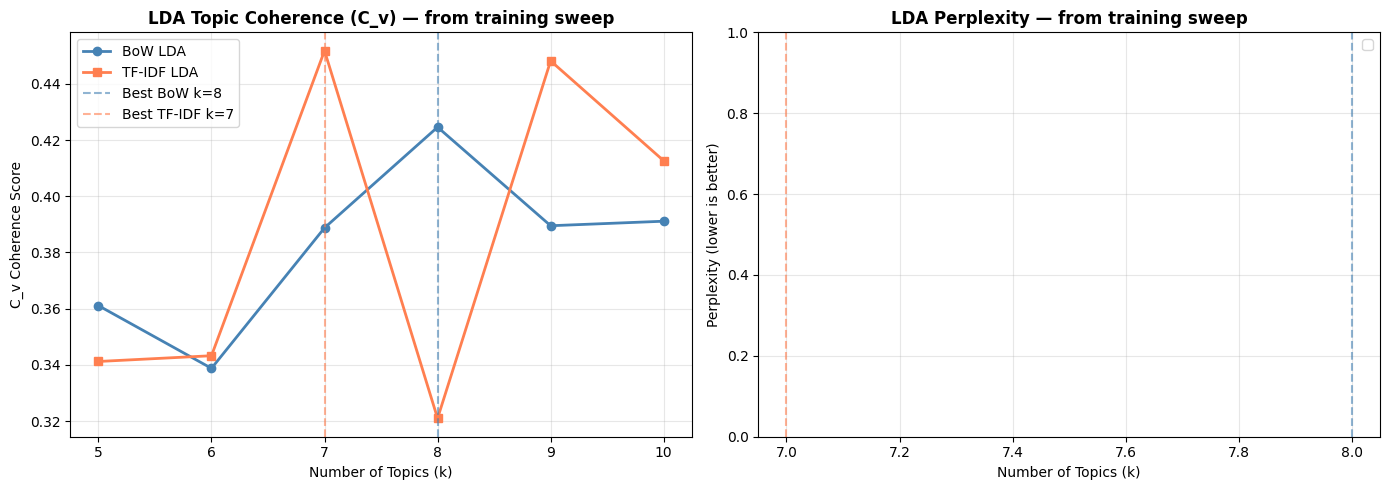

In [ ]:
# Extract coherence / perplexity arrays from saved training results
# Handles both DataFrame and list-of-dict formats.
def extract_eval_series(results, coherence_key='coherence_score', perplexity_key='perplexity'):
    if isinstance(results, pd.DataFrame):
        coherence  = results[coherence_key].tolist()  if coherence_key  in results.columns else []
        perplexity = results[perplexity_key].tolist() if perplexity_key in results.columns else []
        k_vals     = results['n_topics'].tolist()      if 'n_topics'     in results.columns else list(range(len(results)))
    elif isinstance(results, list) and len(results) > 0 and isinstance(results[0], dict):
        coherence  = [r.get(coherence_key,  r.get('coherence',  None)) for r in results]
        perplexity = [r.get(perplexity_key, r.get('perplexity', None)) for r in results]
        k_vals     = [r.get('n_topics', i+2) for i, r in enumerate(results)]
    else:
        coherence, perplexity, k_vals = [], [], []
    return k_vals, coherence, perplexity

k_bow,   coh_bow,   perp_bow   = extract_eval_series(results_bow)
k_tfidf, coh_tfidf, perp_tfidf = extract_eval_series(results_tfidf)

# Coherence 
fig, ax = plt.subplots(figsize=(8, 5))

if coh_bow:
    ax.plot(k_bow,   coh_bow,   marker='o', linewidth=2, color='steelblue', label='BoW LDA')
if coh_tfidf:
    ax.plot(k_tfidf, coh_tfidf, marker='s', linewidth=2, color='coral',     label='TF-IDF LDA')
    
ax.axvline(best_bow_n_topics,   color='steelblue', linestyle='--', alpha=0.6,
                label=f'Best BoW k={best_bow_n_topics}')
ax.axvline(best_tfidf_n_topics, color='coral',     linestyle='--', alpha=0.6,
                label=f'Best TF-IDF k={best_tfidf_n_topics}')
                
ax.set_title('LDA Topic Coherence (C_v) — from training sweep', fontweight='bold')
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('C_v Coherence Score')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
    
plt.savefig(os.path.join(figures_dir, 'evaluation_lda_coherence_perplexity.png'),
            dpi=300, 
            bbox_inches='tight'
            )
print(f"Saved figure: evaluation_lda_coherence_perplexity.png")

plt.show()

In [ ]:
# Evaluate loaded best models on held-out test data

corpus_bow_train   = Sparse2Corpus(X_bow_train, documents_columns=False)
corpus_bow_test    = Sparse2Corpus(X_bow_test, documents_columns=False)
corpus_tfidf_train = Sparse2Corpus(X_lda_train, documents_columns=False)
corpus_tfidf_test  = Sparse2Corpus(X_lda_test, documents_columns=False)

bow_train_perp   = np.exp2(-lda_best_bow.log_perplexity(corpus_bow_train))
bow_test_perp    = np.exp2(-lda_best_bow.log_perplexity(corpus_bow_test))
tfidf_train_perp = np.exp2(-lda_best_tfidf.log_perplexity(corpus_tfidf_train))
tfidf_test_perp  = np.exp2(-lda_best_tfidf.log_perplexity(corpus_tfidf_test))

gap_bow   = bow_test_perp   - bow_train_perp
gap_tfidf = tfidf_test_perp - tfidf_train_perp

print("=== Loaded Model Perplexity on Evaluation Data ===")
print(f"  BoW   LDA (k={best_bow_n_topics}):  train={bow_train_perp:.1f}   test={bow_test_perp:.1f}   gap={gap_bow:+.1f}")
print(f"  TF-IDF LDA (k={best_tfidf_n_topics}): train={tfidf_train_perp:.1f}   test={tfidf_test_perp:.1f}   gap={gap_tfidf:+.1f}")
print()
for name, gap in [('BoW', gap_bow), ('TF-IDF', gap_tfidf)]:
    if gap > 100:
        msg = '⚠ Potential overfit — large train→test perplexity jump'
    elif gap > 30:
        msg = 'Moderate gap — model generalises reasonably'
    else:
        msg = '✓ Small gap — model generalises well to unseen data'
    print(f"  {name}: {msg}")

=== Loaded Model Perplexity on Evaluation Data ===
  BoW   LDA (k=8):  train=79.0   test=115.9   gap=+36.9
  TF-IDF LDA (k=7): train=184.9   test=426.3   gap=+241.4

  BoW: Moderate gap — model generalises reasonably
  TF-IDF: ⚠ Potential overfit — large train→test perplexity jump


## LDA Topic Assignment Confidence

Saved figure: evaluation_lda_confidence_dist.png


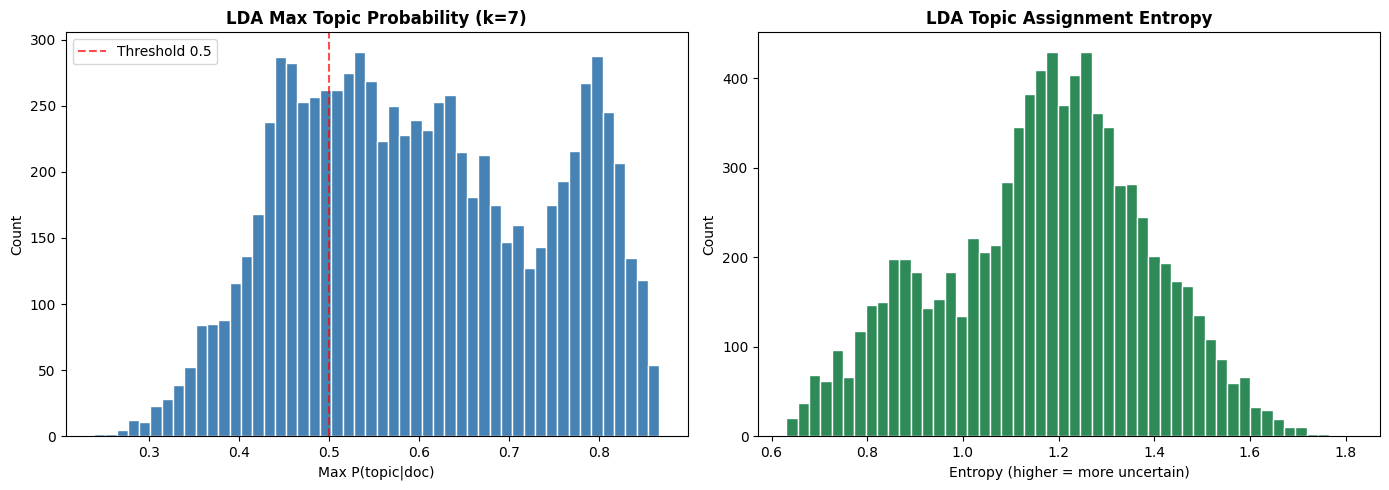

Docs with confident assignment (max_prob > 0.5): 71.9%
Mean entropy   : 1.169
Mean max prob  : 0.601

Train set confidence: 72.6%
Test  set confidence: 69.0%


In [44]:
# lda_topic_dist was built in the 'assign-lda-topics' cell above
df['lda_entropy']  = [entropy(row) for row in lda_topic_dist]
df['lda_max_prob'] = lda_topic_dist.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['lda_max_prob'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'LDA Max Topic Probability (k={best_tfidf_n_topics})', fontweight='bold')
axes[0].set_xlabel('Max P(topic|doc)')
axes[0].set_ylabel('Count')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Threshold 0.5')
axes[0].legend()

axes[1].hist(df['lda_entropy'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('LDA Topic Assignment Entropy', fontweight='bold')
axes[1].set_xlabel('Entropy (higher = more uncertain)')
axes[1].set_ylabel('Count')
plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'evaluation_lda_confidence_dist.png'), 
            dpi=300, 
            bbox_inches='tight'
            )
print(f"Saved figure: evaluation_lda_confidence_dist.png")

plt.show()

confident = (df['lda_max_prob'] > 0.5).mean()
print(f"Docs with confident assignment (max_prob > 0.5): {confident:.1%}")
print(f"Mean entropy   : {df['lda_entropy'].mean():.3f}")
print(f"Mean max prob  : {df['lda_max_prob'].mean():.3f}")
print(f"\nTrain set confidence: {(df['lda_max_prob'].iloc[list(train_idx)] > 0.5).mean():.1%}")
print(f"Test  set confidence: {(df['lda_max_prob'].iloc[list(test_idx)]  > 0.5).mean():.1%}")

## BERTopic Evaluation

In [ ]:
# topics_all was reconstructed from saved bert_train_data / bert_test_data
bt_all = topics_all.copy()
n_outliers = (bt_all == -1).sum()
n_total    = len(bt_all)
print(f"Outliers: {n_outliers} / {n_total} ({n_outliers/n_total:.1%})")

bt_valid = bt_all[bt_all != -1]
unique_topics, topic_counts_bt = np.unique(bt_valid, return_counts=True)
print(f"\nValid topics found: {len(unique_topics)}")
for t, c in sorted(zip(unique_topics, topic_counts_bt), key=lambda x: -x[1]):
    pct = c / len(bt_valid) * 100
    print(f"  Topic {t}: {c} docs ({pct:.1f}%)")
    if pct > 50:
        print(f"MEGA-TOPIC: contains >{pct:.0f}% of non-outlier docs")

sorted_counts = sorted(topic_counts_bt, reverse=True)
if len(sorted_counts) >= 2:
    dominance = sorted_counts[0] / sorted_counts[1]
    print(f"\nDominance ratio (largest/2nd): {dominance:.1f}x")

bt_valid_mask = bt_all != -1
if n_outliers > 0:
    outlier_lengths     = df.loc[bt_all == -1, 'word_count']
    non_outlier_lengths = df.loc[bt_all != -1, 'word_count']
    print(f"\nOutlier mean word count    : {outlier_lengths.mean():.1f}")
    print(f"Non-outlier mean word count: {non_outlier_lengths.mean():.1f}")

Outliers: 1168 / 8469 (13.8%)

Valid topics found: 90
  Topic 0: 365 docs (5.0%)
  Topic 1: 328 docs (4.5%)
  Topic 2: 325 docs (4.5%)
  Topic 4: 323 docs (4.4%)
  Topic 3: 320 docs (4.4%)
  Topic 5: 295 docs (4.0%)
  Topic 6: 217 docs (3.0%)
  Topic 7: 206 docs (2.8%)
  Topic 8: 188 docs (2.6%)
  Topic 13: 163 docs (2.2%)
  Topic 10: 162 docs (2.2%)
  Topic 19: 162 docs (2.2%)
  Topic 14: 161 docs (2.2%)
  Topic 12: 160 docs (2.2%)
  Topic 15: 159 docs (2.2%)
  Topic 9: 158 docs (2.2%)
  Topic 11: 156 docs (2.1%)
  Topic 16: 155 docs (2.1%)
  Topic 17: 154 docs (2.1%)
  Topic 20: 145 docs (2.0%)
  Topic 22: 141 docs (1.9%)
  Topic 18: 140 docs (1.9%)
  Topic 23: 135 docs (1.8%)
  Topic 25: 128 docs (1.8%)
  Topic 21: 126 docs (1.7%)
  Topic 24: 125 docs (1.7%)
  Topic 26: 120 docs (1.6%)
  Topic 29: 109 docs (1.5%)
  Topic 27: 108 docs (1.5%)
  Topic 28: 97 docs (1.3%)
  Topic 30: 89 docs (1.2%)
  Topic 33: 77 docs (1.1%)
  Topic 31: 76 docs (1.0%)
  Topic 35: 76 docs (1.0%)
  Topic 3

## Axis 1 Head-to-Head: LDA vs BERTopic

In [46]:
def topic_purity(topic_labels, true_labels):
    purities = []
    for t in sorted(set(topic_labels)):
        mask = topic_labels == t
        if mask.sum() == 0:
            continue
        type_counts = pd.Series(true_labels[mask]).value_counts()
        purities.append(type_counts.iloc[0] / mask.sum())
    return np.mean(purities)

lda_purity = topic_purity(lda_labels, df['Ticket Type'].values)
bt_purity  = topic_purity(topics_all[bt_valid_mask], df['Ticket Type'].values[bt_valid_mask])

lda_ari_type = adjusted_rand_score(df['Ticket Type'], lda_labels)
lda_nmi_type = normalized_mutual_info_score(df['Ticket Type'], lda_labels)
bt_ari_type  = adjusted_rand_score(df['Ticket Type'].values[bt_valid_mask], topics_all[bt_valid_mask])
bt_nmi_type  = normalized_mutual_info_score(df['Ticket Type'].values[bt_valid_mask], topics_all[bt_valid_mask])

lda_ari_subj = adjusted_rand_score(df['Ticket Subject'], lda_labels)
lda_nmi_subj = normalized_mutual_info_score(df['Ticket Subject'], lda_labels)
bt_ari_subj  = adjusted_rand_score(df['Ticket Subject'].values[bt_valid_mask], topics_all[bt_valid_mask])
bt_nmi_subj  = normalized_mutual_info_score(df['Ticket Subject'].values[bt_valid_mask], topics_all[bt_valid_mask])

comparison = pd.DataFrame({
    'Metric': ['Topics Found', 'Outlier %', 'Mean Topic Purity (Type)',
               'ARI vs Ticket Type', 'NMI vs Ticket Type',
               'ARI vs Ticket Subject', 'NMI vs Ticket Subject',
               'Train Perplexity', 'Test Perplexity'],
    f'LDA TF-IDF (k={best_tfidf_n_topics})': [
        best_tfidf_n_topics, '0.0%', f'{lda_purity:.3f}',
        f'{lda_ari_type:.4f}', f'{lda_nmi_type:.4f}',
        f'{lda_ari_subj:.4f}', f'{lda_nmi_subj:.4f}',
        f'{tfidf_train_perp:.1f}', f'{tfidf_test_perp:.1f}',
    ],
    'BERTopic': [
        len(unique_topics), f'{n_outliers/n_total:.1%}', f'{bt_purity:.3f}',
        f'{bt_ari_type:.4f}', f'{bt_nmi_type:.4f}',
        f'{bt_ari_subj:.4f}', f'{bt_nmi_subj:.4f}',
        'N/A', 'N/A',
    ],
})
print(comparison.to_string(index=False))

                  Metric LDA TF-IDF (k=7) BERTopic
            Topics Found                7       90
               Outlier %             0.0%    13.8%
Mean Topic Purity (Type)            0.215    0.285
      ARI vs Ticket Type          -0.0001   0.0000
      NMI vs Ticket Type           0.0006   0.0089
   ARI vs Ticket Subject           0.0000   0.0001
   NMI vs Ticket Subject           0.0023   0.0308
        Train Perplexity            184.9      N/A
         Test Perplexity            426.3      N/A


## Axis 2 Evaluation: VADER vs TextBlob

In [47]:
print(f"VADER compound — mean: {df['vader_compound'].mean():.3f}, "
      f"std: {df['vader_compound'].std():.3f}, "
      f"range: [{df['vader_compound'].min():.3f}, {df['vader_compound'].max():.3f}]")
print(f"TextBlob polarity — mean: {df['tb_polarity'].mean():.3f}, "
      f"std: {df['tb_polarity'].std():.3f}, "
      f"range: [{df['tb_polarity'].min():.3f}, {df['tb_polarity'].max():.3f}]")

print("\nVADER label distribution:")
print(df['vader_label'].value_counts(normalize=True).round(3))
print("\nTextBlob label distribution:")
print(df['tb_label'].value_counts(normalize=True).round(3))

groups_vader = [g['vader_compound'].values for _, g in df.groupby('Ticket Type')]
groups_tb    = [g['tb_polarity'].values    for _, g in df.groupby('Ticket Type')]
stat_v, p_v  = kruskal(*groups_vader)
stat_t, p_t  = kruskal(*groups_tb)
print(f"\nKruskal-Wallis (sentiment ~ Ticket Type):")
print(f"  VADER:    H={stat_v:.2f}, p={p_v:.4f} {'→ no significant difference' if p_v > 0.05 else '→ significant difference'}")
print(f"  TextBlob: H={stat_t:.2f}, p={p_t:.4f} {'→ no significant difference' if p_t > 0.05 else '→ significant difference'}")

groups_vader_subj = [g['vader_compound'].values for _, g in df.groupby('Ticket Subject')]
groups_tb_subj    = [g['tb_polarity'].values    for _, g in df.groupby('Ticket Subject')]
stat_vs, p_vs     = kruskal(*groups_vader_subj)
stat_ts, p_ts     = kruskal(*groups_tb_subj)
print(f"\nKruskal-Wallis (sentiment ~ Ticket Subject):")
print(f"  VADER:    H={stat_vs:.2f}, p={p_vs:.4f} {'→ no significant difference' if p_vs > 0.05 else '→ significant difference'}")
print(f"  TextBlob: H={stat_ts:.2f}, p={p_ts:.4f} {'→ no significant difference' if p_ts > 0.05 else '→ significant difference'}")

VADER compound — mean: 0.256, std: 0.422, range: [-0.955, 0.985]
TextBlob polarity — mean: 0.060, std: 0.202, range: [-0.750, 1.000]

VADER label distribution:
vader_label
Positive    0.708
Negative    0.249
Neutral     0.043
Name: proportion, dtype: float64

TextBlob label distribution:
tb_label
Positive    0.445
Neutral     0.330
Negative    0.225
Name: proportion, dtype: float64

Kruskal-Wallis (sentiment ~ Ticket Type):
  VADER:    H=1.58, p=0.8119 → no significant difference
  TextBlob: H=2.25, p=0.6893 → no significant difference

Kruskal-Wallis (sentiment ~ Ticket Subject):
  VADER:    H=13.05, p=0.5987 → no significant difference
  TextBlob: H=12.12, p=0.6698 → no significant difference


## Sentiment × Topic Interaction

Saved figure: evaluation_sentiment_vs_topic.png


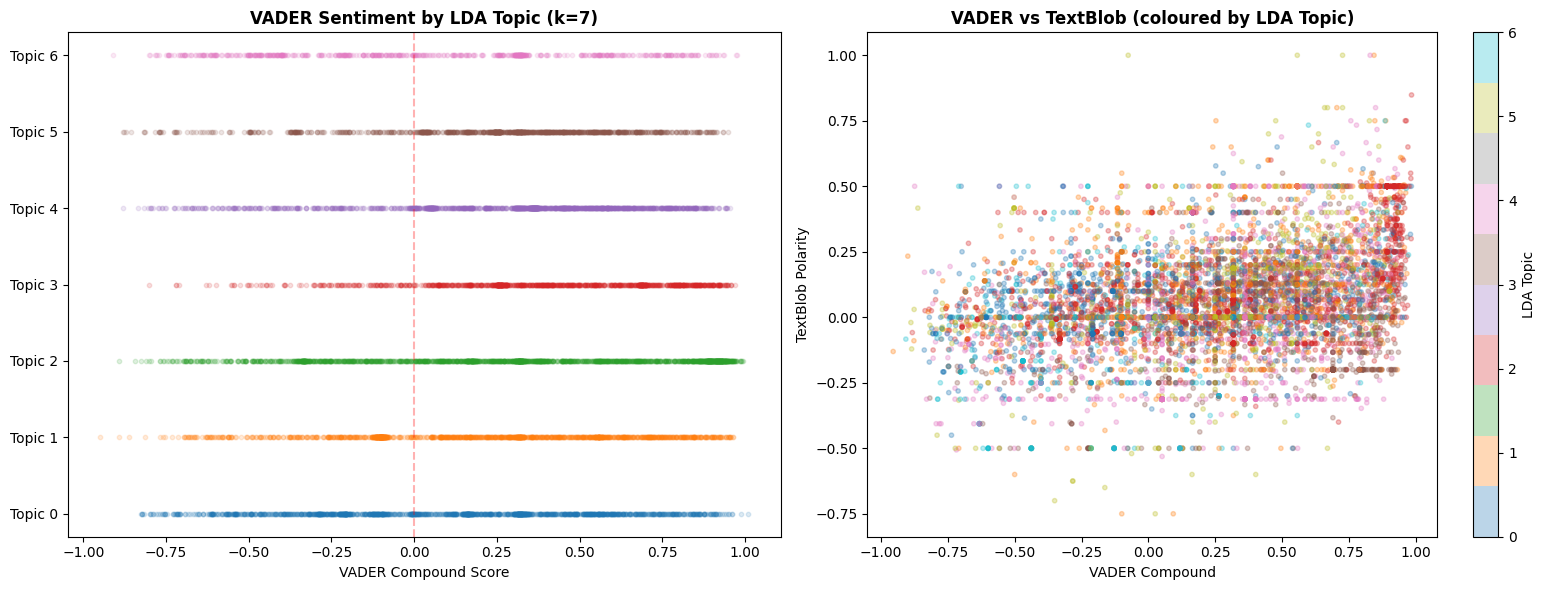

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for topic_id in range(best_tfidf_n_topics):
    mask = df['lda_topic'] == topic_id
    axes[0].scatter(
        df.loc[mask, 'vader_compound'] + np.random.normal(0, 0.01, mask.sum()),
        [topic_id] * mask.sum(), alpha=0.15, s=10
    )
axes[0].set_yticks(range(best_tfidf_n_topics))
axes[0].set_yticklabels([f'Topic {i}' for i in range(best_tfidf_n_topics)])
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_title(f'VADER Sentiment by LDA Topic (k={best_tfidf_n_topics})', fontweight='bold')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.3)

scatter = axes[1].scatter(
    df['vader_compound'], df['tb_polarity'],
    c=df['lda_topic'], cmap='tab10', alpha=0.3, s=10
)
axes[1].set_xlabel('VADER Compound')
axes[1].set_ylabel('TextBlob Polarity')
axes[1].set_title('VADER vs TextBlob (coloured by LDA Topic)', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='LDA Topic')
plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'evaluation_sentiment_vs_topic.png'), 
            dpi=300, 
            bbox_inches='tight')
print(f"Saved figure: evaluation_sentiment_vs_topic.png")

plt.show()

## Consistency & Robustness Across Methods

Tests consistency across algorithms and representations using the **loaded clustering labels**.
The LDA generalisation gap (train vs test perplexity above) already captures model stability;
there is no need to retrain models with different seeds here.

--- Algorithm Consistency (KMeans vs HAC, same representation) ---
  TF-IDF: ARI = -0.0939
  SBERT:  ARI = -0.0003

--- Representation Consistency (TF-IDF vs SBERT, same algorithm) ---
  KMeans: ARI = 0.0600
  HAC:    ARI = -0.0009

--- BERTopic vs Clustering ---
  BERTopic vs TF-IDF KMeans: ARI = 0.0536
  BERTopic vs SBERT KMeans:  ARI = 0.0674

--- LDA Robustness: Confidence Gap (train vs test) ---
  Train confident assignments: 72.6%
  Test  confident assignments: 69.0%
  Gap: 3.6% — ✓ Stable

--- Full Cross-Method Agreement Matrix (ARI) ---
           KM-TF   KM-SB  HAC-TF  HAC-SB     LDA  BERTopic
KM-TF     1.0000  0.0600 -0.0939 -0.0006  0.0838    0.0357
KM-SB     0.0600  1.0000 -0.0252 -0.0003  0.0393    0.0528
HAC-TF   -0.0939 -0.0252  1.0000 -0.0009  0.0017    0.0042
HAC-SB   -0.0006 -0.0003 -0.0009  1.0000 -0.0000   -0.0001
LDA       0.0838  0.0393  0.0017 -0.0000  1.0000    0.1329
BERTopic  0.0357  0.0528  0.0042 -0.0001  0.1329    1.0000
Saved figure: evaluation_ari_matrix.

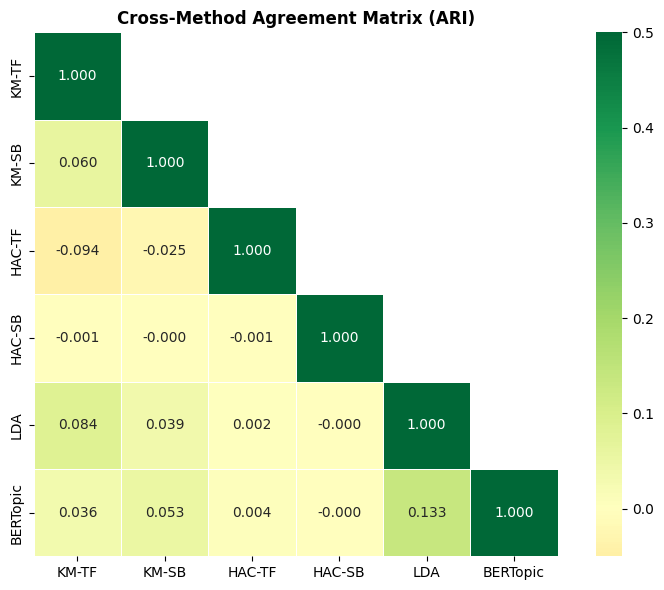

In [49]:
# ── 1. HAC (deterministic) — fit on loaded representations ───────────────────
# HAC is a pure partitioning step with no learned weights; it is correct to
# run it here because it simply repartitions the already-loaded X_tfidf / X_sbert.
hac_tfidf_5 = AgglomerativeClustering(n_clusters=5, metric='cosine', linkage='average')
hac_tfidf_labels = hac_tfidf_5.fit_predict(X_tfidf.toarray())

hac_sbert_5 = AgglomerativeClustering(n_clusters=5, metric='cosine', linkage='average')
hac_sbert_labels = hac_sbert_5.fit_predict(X_sbert)

# ── 2. Algorithm consistency: KMeans vs HAC (same representation) ────────────
ari_km_hac_tfidf = adjusted_rand_score(km_tfidf_labels, hac_tfidf_labels)
ari_km_hac_sbert = adjusted_rand_score(km_sbert_labels, hac_sbert_labels)
print("--- Algorithm Consistency (KMeans vs HAC, same representation) ---")
print(f"  TF-IDF: ARI = {ari_km_hac_tfidf:.4f}")
print(f"  SBERT:  ARI = {ari_km_hac_sbert:.4f}")

# ── 3. Representation consistency: TF-IDF vs SBERT (same algorithm) ──────────
ari_tfidf_sbert_km  = adjusted_rand_score(km_tfidf_labels, km_sbert_labels)
ari_tfidf_sbert_hac = adjusted_rand_score(hac_tfidf_labels, hac_sbert_labels)
print("\n--- Representation Consistency (TF-IDF vs SBERT, same algorithm) ---")
print(f"  KMeans: ARI = {ari_tfidf_sbert_km:.4f}")
print(f"  HAC:    ARI = {ari_tfidf_sbert_hac:.4f}")

# ── 4. BERTopic vs clustering ─────────────────────────────────────────────────
ari_bt_km_tfidf = adjusted_rand_score(km_tfidf_labels[bt_valid_mask], topics_all[bt_valid_mask])
ari_bt_km_sbert = adjusted_rand_score(km_sbert_labels[bt_valid_mask], topics_all[bt_valid_mask])
print("\n--- BERTopic vs Clustering ---")
print(f"  BERTopic vs TF-IDF KMeans: ARI = {ari_bt_km_tfidf:.4f}")
print(f"  BERTopic vs SBERT KMeans:  ARI = {ari_bt_km_sbert:.4f}")

# ── 5. LDA train-vs-test confidence gap as a robustness proxy ────────────────
train_conf = (df['lda_max_prob'].iloc[list(train_idx)] > 0.5).mean()
test_conf  = (df['lda_max_prob'].iloc[list(test_idx)]  > 0.5).mean()
conf_gap   = abs(train_conf - test_conf)
print(f"\n--- LDA Robustness: Confidence Gap (train vs test) ---")
print(f"  Train confident assignments: {train_conf:.1%}")
print(f"  Test  confident assignments: {test_conf:.1%}")
print(f"  Gap: {conf_gap:.1%} — {'✓ Stable' if conf_gap < 0.05 else '⚠ Unstable'}")

# ── 6. Full cross-method agreement matrix ────────────────────────────────────
bt_for_compare = topics_all.copy()
bt_for_compare[bt_for_compare == -1] = 99

all_label_sets = {
    'KM-TF':   km_tfidf_labels,
    'KM-SB':   km_sbert_labels,
    'HAC-TF':  hac_tfidf_labels,
    'HAC-SB':  hac_sbert_labels,
    'LDA':     lda_labels,
    'BERTopic': bt_for_compare,
}

methods    = list(all_label_sets.keys())
ari_matrix = pd.DataFrame(
    np.zeros((len(methods), len(methods))), index=methods, columns=methods
)
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i == j:
            ari_matrix.iloc[i, j] = 1.0
        elif i < j:
            a = adjusted_rand_score(all_label_sets[m1], all_label_sets[m2])
            ari_matrix.iloc[i, j] = a
            ari_matrix.iloc[j, i] = a

print("\n--- Full Cross-Method Agreement Matrix (ARI) ---")
print(ari_matrix.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
mask_upper = np.triu(np.ones_like(ari_matrix, dtype=bool), k=1)
sns.heatmap(ari_matrix.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-0.05, vmax=0.5, ax=ax, mask=mask_upper,
            square=True, linewidths=0.5)
ax.set_title('Cross-Method Agreement Matrix (ARI)', fontweight='bold')
plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'evaluation_ari_matrix.png'), 
            dpi=300, 
            bbox_inches='tight'
            )
print(f"Saved figure: evaluation_ari_matrix.png")

plt.show()

## Coherence & Interpretability of Issue Categories

In [ ]:
# ── 1. LDA per-topic coherence — using the LOADED model's components ──────────
print(f"--- LDA Per-Topic Coherence (C_v, k={best_tfidf_n_topics}) ---")
from gensim.corpora import Dictionary

# Validate and convert a standard Python dictionary to an official Gensim Dictionary object
if isinstance(gensim_dict_tfidf, dict):
    _g = Dictionary()
    first_key = list(gensim_dict_tfidf.keys())[0]
    
    if isinstance(first_key, int) or (isinstance(first_key, str) and str(first_key).isdigit()):
        _g.id2token = {int(k): str(v) for k, v in gensim_dict_tfidf.items()}
        _g.token2id = {str(v): int(k) for k, v in gensim_dict_tfidf.items()}
    else:
        _g.token2id = {str(k): int(v) for k, v in gensim_dict_tfidf.items()}
        _g.id2token = {int(v): str(k) for k, v in gensim_dict_tfidf.items()}
        
    gensim_dict_tfidf = _g

lda_topic_words = []
for t in range(lda_best_tfidf.num_topics):
    top_idx = [word_id for word_id, prob in lda_best_tfidf.get_topic_terms(t, topn=10)]
    lda_topic_words.append([feature_names_lda[i] for i in top_idx])

cm_lda = CoherenceModel(
    topics=lda_topic_words, texts=train_token_lists,
    dictionary=gensim_dict_tfidf, coherence='c_v'
)
per_topic_cv = cm_lda.get_coherence_per_topic()
overall_cv   = cm_lda.get_coherence()

for t, (words, cv) in enumerate(zip(lda_topic_words, per_topic_cv)):
    print(f"  Topic {t} (C_v={cv:.4f}): {', '.join(words[:6])}")
print(f"\n  Overall C_v: {overall_cv:.4f}")

# ── 2. BERTopic topic coherence — from the loaded model ──────────────────────
print("\n--- BERTopic Per-Topic Coherence (C_v) ---")
bt_topic_info  = topic_model.get_topic_info()
bt_topic_words = []
bt_topic_ids   = []
for _, row in bt_topic_info.iterrows():
    if row['Topic'] == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(row['Topic'])[:10]]
    bt_topic_words.append(words)
    bt_topic_ids.append(row['Topic'])

if bt_topic_words:
    cm_bt = CoherenceModel(
        topics=bt_topic_words, texts=train_token_lists,
        dictionary=gensim_dict_tfidf, coherence='c_v'
    )
    bt_per_topic_cv = cm_bt.get_coherence_per_topic()
    bt_overall_cv   = cm_bt.get_coherence()
    for tid, words, cv in zip(bt_topic_ids, bt_topic_words, bt_per_topic_cv):
        print(f"  Topic {tid} (C_v={cv:.4f}): {', '.join(words[:6])}")
    print(f"\n  Overall C_v: {bt_overall_cv:.4f}")
else:
    bt_overall_cv = float('nan')
    print("  No valid BERTopic topics for coherence calculation")

# ── 3. Clustering interpretability via top TF-IDF terms ──────────────────────
print("\n--- Cluster Interpretability: Top TF-IDF Terms per Cluster ---")
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
X_tfidf_dense = X_tfidf.toarray()

cluster_topic_words = []
for method_name, labels_c in [('KMeans-TF', km_tfidf_labels), ('HAC-TF', hac_tfidf_labels)]:
    print(f"\n  {method_name}:")
    method_words = []
    for c in sorted(set(labels_c)):
        mask = labels_c == c
        centroid = X_tfidf_dense[mask].mean(axis=0)
        top_idx  = centroid.argsort()[-10:][::-1]
        words    = [feature_names_tfidf[i] for i in top_idx]
        method_words.append(words)
        print(f"    Cluster {c}: {', '.join(words[:6])}")
    cluster_topic_words.append((method_name, method_words))

# KMeans-TF cluster coherence
km_cluster_words = cluster_topic_words[0][1]
cm_km   = CoherenceModel(
    topics=km_cluster_words, texts=train_token_lists,
    dictionary=gensim_dict_tfidf, coherence='c_v'
)
km_cv     = cm_km.get_coherence()
km_per_cv = cm_km.get_coherence_per_topic()
print(f"\n  KMeans-TF Overall C_v: {km_cv:.4f}")
for c, cv in enumerate(km_per_cv):
    print(f"    Cluster {c}: C_v = {cv:.4f}")

# ── 4. Summary comparison ─────────────────────────────────────────────────────
print("\n--- Coherence Comparison Summary ---")
coherence_summary = pd.DataFrame({
    'Method':           [f'LDA (k={best_tfidf_n_topics})', 'BERTopic', 'KMeans-TF (k=5)'],
    'Overall C_v':      [f'{overall_cv:.4f}',
                         f'{bt_overall_cv:.4f}' if not np.isnan(bt_overall_cv) else 'N/A',
                         f'{km_cv:.4f}'],
    'Topics/Clusters':  [best_tfidf_n_topics, len(bt_topic_ids), 5],
    'Coverage':         ['100%', f'{bt_valid_mask.mean():.1%}', '100%'],
})
print(coherence_summary.to_string(index=False))

# ── 5. Visualise per-topic coherence ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
tick_labels, tick_positions = [], []
x_pos = 0

for cv_val in per_topic_cv:
    ax.bar(x_pos, cv_val, color='steelblue', width=0.7)
    tick_labels.append(f'LDA-{x_pos}')
    tick_positions.append(x_pos)
    x_pos += 1

x_pos += 0.5
if bt_topic_words:
    for i, cv_val in enumerate(bt_per_topic_cv):
        ax.bar(x_pos, cv_val, color='coral', width=0.7)
        tick_labels.append(f'BT-{bt_topic_ids[i]}')
        tick_positions.append(x_pos)
        x_pos += 1

x_pos += 0.5
for i, cv_val in enumerate(km_per_cv):
    ax.bar(x_pos, cv_val, color='seagreen', width=0.7)
    tick_labels.append(f'KM-{i}')
    tick_positions.append(x_pos)
    x_pos += 1

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.set_ylabel('C_v Coherence Score')
ax.set_title('Per-Topic/Cluster Coherence Across Methods', fontweight='bold')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', label='LDA'),
    plt.Rectangle((0,0),1,1, color='coral',     label='BERTopic'),
    plt.Rectangle((0,0),1,1, color='seagreen',  label='KMeans-TF'),
], loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'evaluation_per_topic_coherence.png'), 
            dpi=300, 
            bbox_inches='tight'
            )
print(f"Saved figure: evaluation_per_topic_coherence.png")

plt.show()

--- LDA Per-Topic Coherence (C_v, k=7) ---


## Alignment with Expected Patterns & Initial Clustering

In [ ]:
# ── 1. All methods vs ground truth ───────────────────────────────────────────
print("--- All Methods vs Ground Truth ---")

all_methods = {
    'KMeans-TF': km_tfidf_labels,
    'KMeans-SB': km_sbert_labels,
    'HAC-TF':    hac_tfidf_labels,
    'HAC-SB':    hac_sbert_labels,
    'LDA':       lda_labels,
    'BERTopic':  topics_all,
}

rows = []
for name, labels in all_methods.items():
    if name == 'BERTopic':
        valid    = labels != -1
        ari_type = adjusted_rand_score(df['Ticket Type'].values[valid], labels[valid])
        nmi_type = normalized_mutual_info_score(df['Ticket Type'].values[valid], labels[valid])
        ari_subj = adjusted_rand_score(df['Ticket Subject'].values[valid], labels[valid])
        nmi_subj = normalized_mutual_info_score(df['Ticket Subject'].values[valid], labels[valid])
        coverage = f'{valid.mean():.1%}'
    else:
        ari_type = adjusted_rand_score(df['Ticket Type'], labels)
        nmi_type = normalized_mutual_info_score(df['Ticket Type'], labels)
        ari_subj = adjusted_rand_score(df['Ticket Subject'], labels)
        nmi_subj = normalized_mutual_info_score(df['Ticket Subject'], labels)
        coverage = '100%'
    rows.append({
        'Method': name, 'Coverage': coverage,
        'ARI(Type)': f'{ari_type:.4f}', 'NMI(Type)': f'{nmi_type:.4f}',
        'ARI(Subj)': f'{ari_subj:.4f}', 'NMI(Subj)': f'{nmi_subj:.4f}',
    })

alignment_df = pd.DataFrame(rows)
print(alignment_df.to_string(index=False))

# ── 2. Heatmaps: each method vs Ticket Type ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, labels) in enumerate(all_methods.items()):
    if idx >= 6:
        break
    if name == 'BERTopic':
        valid = labels != -1
        ct    = pd.crosstab(labels[valid], df['Ticket Type'].values[valid])
    else:
        ct = pd.crosstab(labels, df['Ticket Type'])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[idx],
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name} vs Ticket Type', fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('Cluster/Topic')

plt.suptitle('All Methods vs Ticket Type (Row-Normalised Proportions)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'evaluation_all_methods_vs_type.png'), 
            dpi=300, 
            bbox_inches='tight')
print(f"Saved figure: evaluation_all_methods_vs_type.png")

plt.show()

# ── 3. LDA topics: pattern analysis ──────────────────────────────────────────
print(f"\n--- Pattern Analysis: LDA Topics vs Intuitive Issue Categories ---")
for t in range(best_tfidf_n_topics):
    mask   = df['lda_topic'] == t
    n      = mask.sum()
    top_idx   = [word_id for word_id, prob in lda_best_tfidf.get_topic_terms(t, topn=8)]
    top_words = [feature_names_lda[i] for i in top_idx]
    type_mode = df.loc[mask, 'Ticket Type'].value_counts()
    subj_mode = df.loc[mask, 'Ticket Subject'].value_counts()
    type_ent  = entropy(type_mode.values / type_mode.sum())
    subj_ent  = entropy(subj_mode.values / subj_mode.sum())
    top_prod  = df.loc[mask, 'Product Purchased'].value_counts().head(2)

    print(f"  Topic {t} ({n} docs):")
    print(f"    Keywords: {', '.join(top_words)}")
    print(f"    Ticket Type distribution (entropy={type_ent:.2f}):")
    for tt, c in type_mode.head(3).items():
        print(f"      {tt}: {c} ({c/n*100:.1f}%)")
    print(f"    Ticket Subject distribution (entropy={subj_ent:.2f}):")
    for ts, c in subj_mode.head(3).items():
        print(f"      {ts}: {c} ({c/n*100:.1f}%)")
    print(f"    Top products: {', '.join([f'{p} ({c})' for p, c in top_prod.items()])}")
    print(f"    → {'Mixed topic: spans multiple ticket types equally' if type_ent > 1.3 else f'Skewed toward: {type_mode.index[0]}'}")
    print()

# ── 4. LDA topic ↔ clustering alignment ──────────────────────────────────────
print("--- LDA Topic ↔ Clustering Alignment Detail ---")
for t in range(best_tfidf_n_topics):
    lda_mask    = lda_labels == t
    km_in_topic = km_tfidf_labels[lda_mask]
    km_mode     = pd.Series(km_in_topic).value_counts()
    overlap_pct = km_mode.iloc[0] / lda_mask.sum() * 100
    sb_in_topic = km_sbert_labels[lda_mask]
    sb_mode     = pd.Series(sb_in_topic).value_counts()
    sb_overlap_pct = sb_mode.iloc[0] / lda_mask.sum() * 100

    print(f"  LDA Topic {t}:")
    print(f"    Best TF-IDF cluster match: Cluster {km_mode.index[0]} ({overlap_pct:.1f}% overlap)")
    print(f"    Best SBERT cluster match:  Cluster {sb_mode.index[0]} ({sb_overlap_pct:.1f}% overlap)")
    print(f"    → {'Strong alignment with TF-IDF clustering' if overlap_pct > 50 else 'Weak alignment — topic spans multiple clusters'}")
    print()

# Error Analysis

In [ ]:
# ── 1. Sentiment disagreements ────────────────────────────────────────────────
disagree_mask = df['vader_label'] != df['tb_label']
print(f"Sentiment label disagreements: {disagree_mask.sum()} / {len(df)} ({disagree_mask.mean():.1%})")
print("\nDisagreement breakdown:")
print(pd.crosstab(df.loc[disagree_mask, 'vader_label'], df.loc[disagree_mask, 'tb_label'],
                   rownames=['VADER'], colnames=['TextBlob']))

print("\n--- Sample Disagreement Cases ---")
disagree_df = df[disagree_mask].sample(min(5, disagree_mask.sum()), random_state=42)
for _, row in disagree_df.iterrows():
    print(f"  VADER={row['vader_label']} ({row['vader_compound']:.3f}) | "
          f"TB={row['tb_label']} ({row['tb_polarity']:.3f})")
    print(f"  Text: {row['Ticket Description'][:150]}...")
    print()

# ── 2. LDA uncertain assignments ─────────────────────────────────────────────
print("--- LDA Uncertain Assignments (entropy > 75th percentile) ---")
q75       = df['lda_entropy'].quantile(0.75)
uncertain = df[df['lda_entropy'] > q75].sample(
    min(5, (df['lda_entropy'] > q75).sum()), random_state=42
)
for _, row in uncertain.iterrows():
    topic_dist = lda_topic_dist[row.name]
    top2       = topic_dist.argsort()[-2:][::-1]
    print(f"  Assigned: Topic {row['lda_topic']} (p={topic_dist[int(row['lda_topic'])]:.2f}), "
          f"Runner-up: Topic {top2[1]} (p={topic_dist[top2[1]]:.2f})")
    print(f"  Text: {row['Ticket Description'][:150]}...")
    print()

# ── 3. BERTopic outliers ──────────────────────────────────────────────────────
if (topics_all == -1).sum() > 0:
    print("--- BERTopic Outlier Samples ---")
    outlier_df = df[topics_all == -1].sample(min(5, (topics_all == -1).sum()), random_state=42)
    for _, row in outlier_df.iterrows():
        print(f"  Type: {row['Ticket Type']} | Subject: {row['Ticket Subject']}")
        print(f"  Text: {row['Ticket Description'][:150]}...")
        print()

# Issue Discovery: Labelling & Ranking

## Issue Labelling: Naming Discovered Topics

In [ ]:
# Inspect top words to decide labels
print(f"=== LDA Topic Top Words — loaded model (k={best_tfidf_n_topics}) ===")
for t in range(best_tfidf_n_topics):
    top_idx   = [word_id for word_id, prob in lda_best_tfidf.get_topic_terms(t, topn=10)]
    top_words = [feature_names_lda[i] for i in top_idx]
    print(f"  Topic {t}: {', '.join(top_words)}")

# UPDATE THESE after inspecting your actual top words!
topic_labels = {
    0: "Payment & Billing Issues",
    1: "Network & Connectivity Problems",
    2: "Software Errors & Crashes",
    3: "Account Access & Security",
    4: "Hardware & Peripheral Faults",
}
# Extend if best_tfidf_n_topics > 5
for t in range(5, best_tfidf_n_topics):
    topic_labels[t] = f"Topic {t} (unlabelled)"

df['issue_label'] = df['lda_topic'].map(topic_labels)

print("\n=== Issue Label Distribution ===")
label_counts = df['issue_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label:40s} {count:5d} ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
label_counts.sort_values().plot(kind='barh', ax=ax,
    color=sns.color_palette('tab10', len(label_counts)))
ax.set_title('Discovered Issue Categories (LDA Topic Labels)', fontweight='bold')
ax.set_xlabel('Number of Tickets')
for i, (v, label) in enumerate(zip(label_counts.sort_values().values,
                                    label_counts.sort_values().index)):
    ax.text(v + 20, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=10)
plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'evaluation_issue_label_distribution.png'), 
            dpi=300, 
            bbox_inches='tight')
print(f"Saved figure: evaluation_issue_label_distribution.png")

plt.show()

## Ranking Issues by Importance

In [ ]:
issue_stats = df.groupby('issue_label').agg(
    volume=('issue_label', 'size'),
    mean_sentiment=('vader_compound', 'mean'),
    std_sentiment=('vader_compound', 'std'),
    high_priority_pct=('Ticket Priority', lambda x: (x.isin(['Critical', 'High'])).mean()),
    unique_products=('Product Purchased', 'nunique'),
).reset_index()

# Normalise each factor to [0, 1]
issue_stats['vol_norm']      = issue_stats['volume'] / issue_stats['volume'].max()
issue_stats['neg_norm']      = 1 - (issue_stats['mean_sentiment'] - issue_stats['mean_sentiment'].min()) / \
    (issue_stats['mean_sentiment'].max() - issue_stats['mean_sentiment'].min() + 1e-9)
issue_stats['priority_norm'] = issue_stats['high_priority_pct'] / issue_stats['high_priority_pct'].max()

# Composite importance score (equal weighting — adjust if needed)
issue_stats['importance_score'] = (
    0.4 * issue_stats['vol_norm'] +
    0.3 * issue_stats['neg_norm'] +
    0.3 * issue_stats['priority_norm']
)

issue_stats = issue_stats.sort_values('importance_score', ascending=False)

print("=== Issue Ranking by Importance ===\n")
for rank, (_, row) in enumerate(issue_stats.iterrows(), 1):
    print(f"  #{rank} {row['issue_label']}")
    print(f"      Volume: {row['volume']} tickets ({row['volume']/len(df)*100:.1f}%)")
    print(f"      Mean Sentiment: {row['mean_sentiment']:.3f}")
    print(f"      High/Critical Priority: {row['high_priority_pct']:.1%}")
    print(f"      Products Affected: {row['unique_products']}")
    print(f"      Importance Score: {row['importance_score']:.3f}")
    print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = sns.color_palette('Reds_r', len(issue_stats))
issue_stats_sorted = issue_stats.sort_values('importance_score')
axes[0].barh(issue_stats_sorted['issue_label'], issue_stats_sorted['importance_score'], color=colors)
axes[0].set_title('Composite Importance Score', fontweight='bold')
axes[0].set_xlabel('Score (higher = more urgent)')

axes[1].scatter(issue_stats['volume'], issue_stats['mean_sentiment'],
                s=issue_stats['high_priority_pct'] * 500, alpha=0.7,
                c=range(len(issue_stats)), cmap='tab10', edgecolors='black')
for _, row in issue_stats.iterrows():
    axes[1].annotate(row['issue_label'].split('&')[0].strip(),
                     (row['volume'], row['mean_sentiment']),
                     fontsize=8, ha='center', va='bottom')
axes[1].set_xlabel('Ticket Volume')
axes[1].set_ylabel('Mean Sentiment (lower = more negative)')
axes[1].set_title('Volume vs Sentiment (bubble = priority %)', fontweight='bold')

breakdown = issue_stats_sorted.set_index('issue_label')[['vol_norm', 'neg_norm', 'priority_norm']]
breakdown.columns = ['Volume', 'Negativity', 'Priority']
breakdown.plot(kind='barh', stacked=True, ax=axes[2],
               color=['steelblue', 'salmon', 'goldenrod'])
axes[2].set_title('Importance Score Breakdown', fontweight='bold')
axes[2].set_xlabel('Normalised Component Score')
axes[2].legend(loc='lower right')

plt.tight_layout()

# Save figure
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'evaluation_issue_importance_ranking.png'), 
            dpi=300, 
            bbox_inches='tight')
print(f"Saved figure: evaluation_issue_importance_ranking.png")

plt.show()